# makremore part3
这是karpathy zero to heros 的第4集

In [85]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [86]:
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [87]:
len(words)

32033

In [88]:
characters = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(characters)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [89]:
block_size = 3
def build_dataset(words):
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    return X, Y


import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

In [90]:
n_embd = 10
n_hidden = 200

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_embd), generator=g)
W1 = torch.randn((block_size*n_embd, n_hidden), generator=g) * (5 / 3) / ( n_embd * block_size )**0.5   #0.2
b1 = torch.randn(n_hidden, generator=g) * 0.01
W2 = torch.randn((n_hidden, vocab_size), generator=g) * 0.01
b2 = torch.randn(vocab_size, generator=g) * 0 

bngain = torch.ones((1, n_hidden))
bnbias = torch.zeros((1, n_hidden))


parameters = [C, W1, b1, W2, b2, bngain, bnbias]
for p in parameters:
    p.requires_grad = True

In [91]:
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):  

    ix = torch.randint(0, Xtr.shape[0], (batch_size,))
    Xb, Yb = Xtr[ix], Ytr[ix]

    emb = C[Xb]
    embcat = emb.view(emb.shape[0], -1)
    hpreact = embcat @ W1 + b1
    hpreact = (hpreact - hpreact.mean(0, keepdim=True))/(hpreact.std(0, keepdim=True) ) * bngain + bnbias
    h = torch.tanh(hpreact)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Yb)

    for p in parameters:
        p.grad = None
    loss.backward()

    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.item())

  

      0/ 200000: 3.2967
  10000/ 200000: 2.5265
  20000/ 200000: 2.5054
  30000/ 200000: 2.3795
  40000/ 200000: 2.2194
  50000/ 200000: 2.1213
  60000/ 200000: 2.1593
  70000/ 200000: 1.9841
  80000/ 200000: 2.8529
  90000/ 200000: 2.0158
 100000/ 200000: 2.2406
 110000/ 200000: 2.0234
 120000/ 200000: 1.9851
 130000/ 200000: 2.2755
 140000/ 200000: 2.0239
 150000/ 200000: 2.0112
 160000/ 200000: 2.0716
 170000/ 200000: 1.9363
 180000/ 200000: 2.0287
 190000/ 200000: 1.9421


In [92]:
hpreact.mean(0, keepdim=True)

tensor([[ 0.1622, -0.5708, -0.0078, -0.2023, -0.1384, -0.1136, -0.1438, -0.2886,
          0.4525,  0.3359,  0.2693,  0.4135,  0.3039, -0.2234, -0.3561,  0.1166,
          0.0759,  0.0599, -0.0300,  0.5462,  0.1963, -0.1545,  0.2747,  0.2610,
         -0.0609, -0.0803,  0.0281, -0.4901,  0.0861,  0.2183,  0.1870,  0.2004,
         -0.3995, -0.2120,  0.3554, -0.1015,  0.4764,  0.2510, -0.3063, -0.1803,
          0.1861,  0.2172, -0.0113,  0.0293, -0.2672,  0.0443, -0.5883,  0.3572,
         -0.0090, -0.2514,  0.3120, -0.3691, -0.3127, -0.2538, -0.7754,  0.1824,
          0.0694,  0.1783, -0.0730,  0.3158, -0.3118, -0.2491, -0.0867, -0.1151,
         -0.1182,  0.6705, -0.2228, -0.1708,  0.0639,  0.3505, -0.2476, -0.3714,
          0.0895,  0.2670,  0.0536, -0.1516, -0.0286, -0.3268, -0.3708, -0.4375,
         -0.3049,  0.1611,  0.1852, -0.3575,  0.0140, -0.4101,  0.1469, -0.0558,
         -1.5733,  0.3658, -0.0616,  0.0164,  0.2010, -0.4112, -0.3054, -0.1468,
          0.2446,  0.2427,  

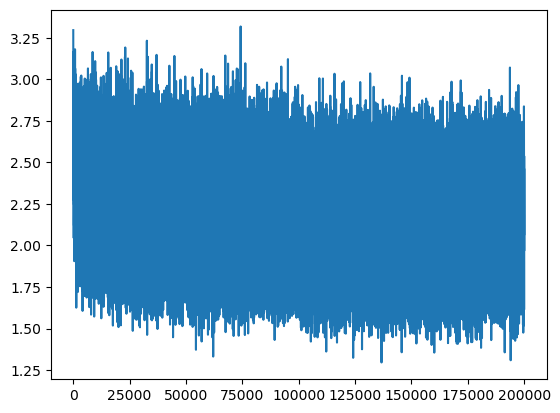

In [93]:
plt.plot(lossi)

In [97]:
@torch.no_grad()
def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte),
    }[split]
    emb = C[x]
    embcat = emb.view(emb.shape[0], -1)
    hpreact = embcat @ W1 + b1
    hpreact = (hpreact - hpreact.mean(0, keepdim=True))/(hpreact.std(0, keepdim=True) ) * bngain + bnbias
    h = torch.tanh(hpreact)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, y)
    print(f'{split}: {loss.item():.4f}')

split_loss('train')
split_loss('val')

train: 2.0671
val: 2.1087


In [95]:
 g = torch.Generator().manual_seed(2147483647 + 10)

 for _ in range(20):
    out = []
    context = [0] * block_size
    while True:
        emb = C[torch.tensor([context])]
        embcat = emb.view(1, -1)
        hpreact = embcat @ W1 + b1
        h = torch.tanh(hpreact)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break
    print(''.join(itos[i] for i in out))

   

naruahxanjbhlvifferrixreviyahntaylahnaxhnnnfarwyn.
trightif.
qumarthciaiivdn.
leggyshnn.
flistquqynnsslingstvi.
bruwwuthl.
viarunixfendubirsabbub.
faliahbtus.
hliffalluqsitylahssyahntqqovonslynnjq.
falasroynnk.
fladhn.
vizordsh.
siyahrynslampklynnrxahmaqissophllyn.
brayah.
qwyntyn.
vivsledgprrstylynnkyceldazquinanikhabbaskanikolmvyevendy.
qoyousorgaryariyannskingcanlaingzss.
stleominnlquroscimbrizysbaksiellahnnnsz.
sadyxhnn.
flusstya.
